In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('hysteresis_correlations.csv')
df.columns = df.columns.str.strip()
numeric_cols = ["SS", "DOC", "Turbidity", "fDOM", "tauc", "ratio", "time"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def linear_regression(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        return np.nan, np.nan, np.nan, x, y
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return slope, intercept, r2, x, y

# viridis colors
constituents = ["SS", "Turbidity", "DOC", "fDOM"]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(constituents)))
color_dict = dict(zip(constituents, colors))

x_vars = {
"ratio": r"$\tau_{\mathrm{peak}}/\tau_c$",
"time": r"$\Delta t_{\tau>\tau_c}$"}

#plt.rcParams.update({"font.size": 14, "axes.labelsize": 17, "axes.titlesize": 16, "xtick.labelsize": 13, "ytick.labelsize": 13})

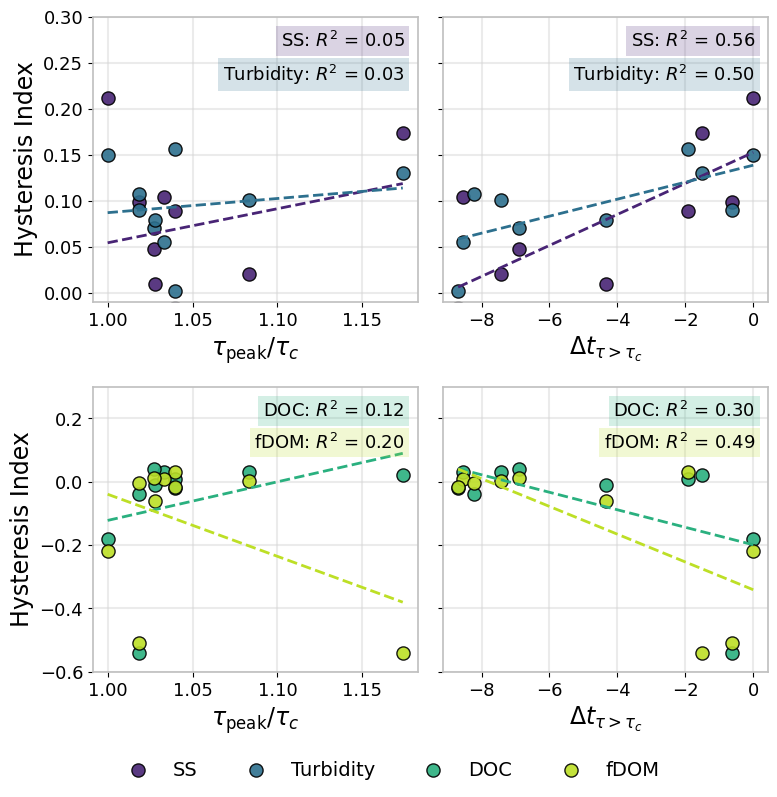

In [ ]:
# subplot structure
plot_layout = [
    {
        "ax_pos": (0, 0),
        "x_col": "ratio",
        "x_label": r"$\tau_{\mathrm{peak}}/\tau_c$",
        "constituents": ["SS", "Turbidity"],
    },
    {
        "ax_pos": (0, 1),
        "x_col": "time",
        "x_label": r"$\Delta t_{\tau>\tau_c}$",
        "constituents": ["SS", "Turbidity"],
    },
    {
        "ax_pos": (1, 0),
        "x_col": "ratio",
        "x_label": r"$\tau_{\mathrm{peak}}/\tau_c$",
        "constituents": ["DOC", "fDOM"],
    },
    {
        "ax_pos": (1, 1),
        "x_col": "time",
        "x_label": r"$\Delta t_{\tau>\tau_c}$",
        "constituents": ["DOC", "fDOM"],
    }
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey="row")

for item in plot_layout:
    row, col = item["ax_pos"]
    ax = axes[row, col]
    x_col = item["x_col"]
    x_label = item["x_label"]
    selected_constituents = item["constituents"]
    r2_texts = []

    for constituent in selected_constituents:
        x = df[x_col].to_numpy()
        y = df[constituent].to_numpy()
        slope, intercept, r2, x_clean, y_clean = linear_regression(x, y)

        # scatter points
        ax.scatter(x_clean, y_clean, s=90, color=color_dict[constituent],
            edgecolor="black", linewidth=1, alpha=0.9, label=constituent)
        
        # regression line
        if len(x_clean) >= 2 and np.isfinite(r2):
            x_line = np.linspace(np.min(x_clean), np.max(x_clean), 100)
            y_line = slope * x_line + intercept

            ax.plot(x_line, y_line, linestyle="--", linewidth=2, color=color_dict[constituent])
            r2_texts.append((constituent, r2, color_dict[constituent]))

    # axes labels and title
    ax.set_xlabel(x_label)

    # grid and spine style
    ax.grid(True, color="lightgray", alpha=0.45, linewidth=1.5)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_color("0.75")
        spine.set_linewidth(1.2)

    # highlighted R² labels
    y_start = 0.95
    y_step = 0.11

    for i, (constituent, r2, color) in enumerate(r2_texts):
        ax.text(
            0.96,
            y_start - i * y_step,
            rf"{constituent}: $R^2$ = {r2:.2f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=13,
            bbox=dict(
                facecolor=color,
                alpha=0.20,
                edgecolor="none",
                boxstyle="square,pad=0.25"
            )
        )


axes[0, 0].set_ylabel("Hysteresis Index")
axes[0, 0].set_ylim(-0.01, 0.3)
axes[1, 0].set_ylabel("Hysteresis Index")
axes[1, 0].set_ylim(-0.6, 0.3)

# one clean legend for the whole figure
handles, labels = [], []

for ax in axes.flatten():
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicate legend labels
unique = dict(zip(labels, handles))

fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0, 1, 0.96])

# save figure
plt.savefig("constituent_regressions.png", dpi=300, bbox_inches="tight")
plt.show()